# Product Trust: Automated Content Integrity Engine

**🎯 Objective:** To design and implement a scalable, automated pipeline that proactively maintains platform health by moderating user-generated content.

**🧭 Strategic Approach:**

* **⚙️ Workflow Automation:** We treat content moderation as an automated "Case" lifecycle—efficient, reproducible, and scalable.
* **📜 Community Standards:** We define content guidelines as a dynamic configuration layer, not hard-coded constraints.
* **⚡ Operational Efficiency:** Our system handles the vast majority of routine moderation automatically, surfacing only high-complexity "Edge Cases" for human review.

> **💡 Note:** This engine transforms moderation from a reactive cost center into a proactive, data-driven product feature.

## 🧠 The Reflex Arc: Biological Modeling of Digital Risk

In Trust & Safety, speed and reliability are paramount. This engine is designed as a **digital reflex arc**—a high-speed, automated system that minimizes latency between content ingestion and safety enforcement.

### The Architectural Blueprint:
1.  **Sensory Input (Ingestion Layer):** Acts as the **afferent pathway**, capturing raw UGC signals from the platform stream.
2.  **Integration Center (Governance/Inference):** The system's **"Central Nervous System."** This layer processes inputs against policy constraints, using a confidence-threshold gateway to decide whether to trigger an immediate motor response or escalate to higher-order cognitive processing (Human Review).
3.  **Motor Response (Enforcement):** The **efferent pathway**, executing the system's decision (e.g., content removal, shadow-banning, or flagging for review).
4.  **Synaptic Plasticity (Feedback Loop):** A critical feature for long-term health; the system maintains logs of enforcement outcomes to "retrain" policy thresholds, mirroring how biological systems adjust their sensitivity to recurring stimuli.

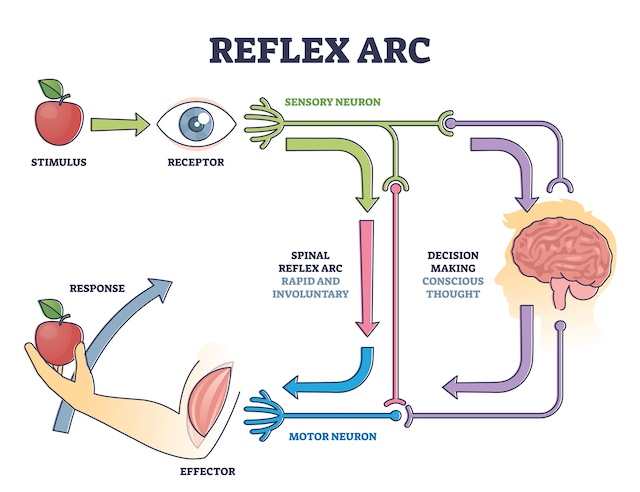

**Insight:**  By viewing content moderation through the lens of a reflex arc, we move beyond "simple classification." We create a system capable of tiered responses—instinctual (automated) blocking for high-confidence threats, and "conscious" (human) deliberation for complex, nuanced cases.

## Section 0: Imports & Environment Setup

In [1]:
import datetime
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import Image, display

## Section 1: Policy Configuration & Guardrails

To ensure our system is scalable and maintains clear logic, we treat our policy definitions as configuration variables. This allows us to update the "Rules of the Road" without needing to rewrite the core inference logic.


* **Policy Pillars:** Defines the specific categories (Toxicity, Misinformation, Spam) that the system monitors.
* **Operational Threshold:** Sets the confidence boundary; any signal falling below this score is escalated to a human reviewer to protect the user experience from false positives.


In [2]:
# --- SECTION 1: Policy Configuration and Guardrails ---
"""
Configures the system's policy guardrails and operational thresholds.
"""

# Define the Guardrails
policy_guardrails = {
    "TOXICITY": "Flag bullying, aggressive, or passive-aggressive language.",
    "MISINFORMATION": "Flag unverified claims regarding health or safety.",
    "SPAM": "Flag repetitive, promotional, or automated-sounding content."
}

# Operational Thresholds
# If confidence is below this, we route to Human Review (HITL)
#I set the human-review threshold at 0.8. In a real-world T&S environment, this is a business-risk decision: we prioritize minimizing False Negatives (missed toxic content) 
#over reducing human headcount in the short term.
human_review_threshold = 0.80 

print("System Initialized: Guardrails and Operational Thresholds set.")

System Initialized: Guardrails and Operational Thresholds set.


## Section 2: Data Generation

To test our pipeline, we simulate real user-generated content. We aren't just generating "data"; we are generating a Platform Feed that includes safe, toxic, and ambiguous posts to stress-test our integrity engine.

* **Healthy Engagement:** Questions, praise, and constructive feedback.
* **Toxic Comments:** Subtle bullying, sarcasm, or aggressive language.
* **Unverified/Spam:** Repetitive or potentially misleading claims.

In [3]:
# --- SECTION 2: Synthetic Platform Traffic ---
"""
Simulates raw data, including complex edge cases (sarcasm, intent, etc.)
to test the model's robustness.
"""

# Nuanced traffic to test 'False Positive' and 'False Negative' scenarios
platform_traffic = [
    ("TOXICITY", "You are the worst developer I have ever seen."), # Clear Toxicity
    ("TOXICITY", "I want to kill this project right now."),       # Contextual (Work-related vs Violence)
    ("MISINFORMATION", "Drinking salt water cures all known diseases."), # Clear Misinfo
    ("SPAM", "Click this link to get 10,000 followers instantly."), # Clear Spam
    ("TOXICITY", "Oh, what a great job, genius. Total failure."),    # Sarcasm (Hard to detect)
    ("SPAM", "I am a bot designed to help you with your tasks.")    # Intentional disclosure
]

print(f"Traffic Simulation: {len(platform_traffic)} nuanced signals ready for ingestion.")

Traffic Simulation: 6 nuanced signals ready for ingestion.


In [4]:
def validate_content_schema(item):
    """
    Validates that a content item contains the required fields for the integrity engine.

    Args:
        item (dict): A single dictionary representing a content signal.

    Returns:
        bool: True if all required keys are present, False otherwise.
    """
    required_keys = ['pillar', 'text', 'timestamp']
    return all(key in item for key in required_keys)

# Transform: Convert raw tuples to a list of clean dictionaries
# This step normalizes the data structure for downstream pipeline compatibility
structured_traffic = [
    {"pillar": pillar, "text": text, "timestamp": datetime.datetime.now().isoformat()} 
    for pillar, text in platform_traffic
]

# Process: Filter items that do not meet the integrity schema
processed_queue = [item for item in structured_traffic if validate_content_schema(item)]

# Summary for audit purposes
print(f"Validation successful: {len(processed_queue)} items passed.")
df = pd.DataFrame(processed_queue)
print(df.head())

Validation successful: 6 items passed.
           pillar                                               text  \
0        TOXICITY      You are the worst developer I have ever seen.   
1        TOXICITY             I want to kill this project right now.   
2  MISINFORMATION      Drinking salt water cures all known diseases.   
3            SPAM  Click this link to get 10,000 followers instan...   
4        TOXICITY       Oh, what a great job, genius. Total failure.   

                    timestamp  
0  2026-04-21T19:09:57.891872  
1  2026-04-21T19:09:57.891880  
2  2026-04-21T19:09:57.891883  
3  2026-04-21T19:09:57.891885  
4  2026-04-21T19:09:57.891887  


## Section 3: Processing Pipeline

Every post is evaluated against our standards, and the outcome is automatically routed to the appropriate "queue." 

* **Inference Logic :** Evaluates content against keywords and context to determine a "Flag" or "Allow" decision.
* **Confidence Scoring:** Quantifies the model's certainty, which is critical for making routing decisions*.
* **Dual-Queue Routing:** Dynamically sorts content into either the moderation_queue (Automated) or the human_review_queue (Manual Stewardship).

In [5]:
# --- SECTION 3: The automated workflow (Inference Pipeline + HITL) ---

moderation_queue = []     # Automated decisions
human_review_queue = []   # Manual decisions (HITL)

def run_inference(text: str, pillar: str) -> dict:
    """
    Simulates inference with confidence scoring.
    """
    # Simulate logic: 
    # 'worst', 'salt water', 'link' -> High confidence flag
    # 'kill', 'genius' -> Low confidence (Edge cases)
    flag_keywords_high = ['worst', 'salt water', 'link', 'followers']
    flag_keywords_low = ['kill', 'genius']
    
    if any(word in text.lower() for word in flag_keywords_high):
        return {"decision": "Flag", "confidence": 0.95}
    elif any(word in text.lower() for word in flag_keywords_low):
        return {"decision": "Flag", "confidence": 0.50} # Ambiguous
    else:
        return {"decision": "Allow", "confidence": 0.99}

# Process the traffic
for pillar, text in platform_traffic:
    inference = run_inference(text, pillar)
    
    # Human-in-the-Loop (HITL) Routing
    if inference['confidence'] < human_review_threshold:
        inference['route'] = "HUMAN_REVIEW"
        human_review_queue.append({'post': text, 'reason': 'Low Confidence Score'})
    else:
        inference['route'] = "AUTO_ACTION"
        
    inference.update({'post_content': text, 'pillar': pillar, 'timestamp': datetime.datetime.now().isoformat()})
    moderation_queue.append(inference)

print(f"Pipeline Complete: {len(moderation_queue)} signals processed.")

Pipeline Complete: 6 signals processed.


## Section 3.5: Quality Gate

Before we visualize any data, we pass it through a "Defensive Barrier." This ensures that our analytics are built on clean, valid data and catches any system failures (like model drift) before they reach the dashboard.

* **Empty State Check :** Prevents the dashboard from crashing if the pipeline has no data.
* **Drift :** Quantifies the model's certainty, which is critical for making routing decisions*.
* **Dual-Queue Routing:** Dynamically sorts content into either the moderation_queue (Automated) or the human_review_queue (Manual Stewardship).

In [6]:
# --- SECTION 3.5: Quality Gate ---
"""
Ensures structural integrity and prevents Model Drift before dashboarding.
"""

def run_quality_gate(queue):
    if not queue: return False, "CRITICAL: Queue empty."
    
    # Check for Model Drift (e.g., if too many items are routed to Human Review)
    total = len(queue)
    human_pct = len(human_review_queue) / total
    if human_pct > 0.5: 
        return False, f"DRIFT DETECTED: {human_pct:.0%} routed to human review. Model too sensitive."
    
    return True, "PASSED"

is_valid, msg = run_quality_gate(moderation_queue)
print(f"Quality Gate Status: {msg}")

Quality Gate Status: PASSED


## Section 4: Platform Health Dashboard

This is where we visualize our efficiency. We transform the raw logs into Key Performance Indicators (KPIs) to provide executive visibility into system performance.

* **Automated Efficiency :** The percentage of content handled by AI without human intervention.
* **Human-in-the-Loop Volume :** The list of high-complexity items surfacing for human review.
* **Operational Insight:** By automating the baseline moderation, we reduce human reviewer burnout and increase reaction speed to platform abuse.

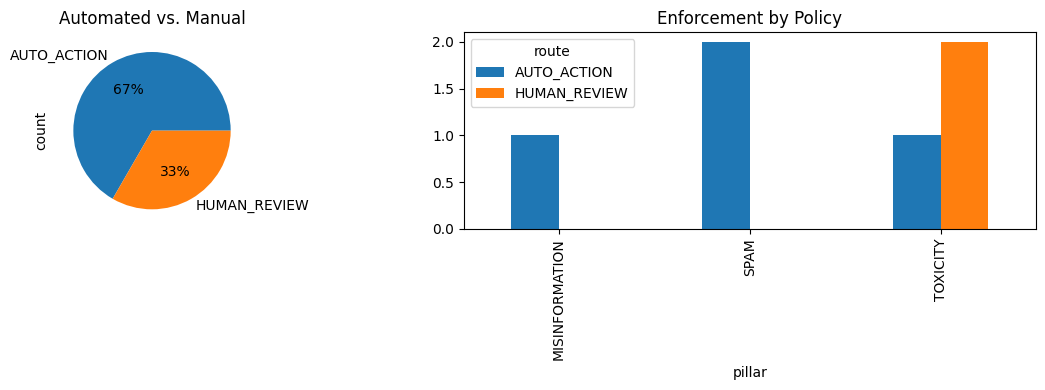

In [7]:
# 1. Convert data 
df = pd.DataFrame(moderation_queue) 

# 2. Simple Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart 1: Routing
df['route'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.0f%%')
axes[0].set_title('Automated vs. Manual')

# Chart 2: Enforcement
pd.crosstab(df['pillar'], df['route']).plot(kind='bar', ax=axes[1])
axes[1].set_title('Enforcement by Policy')

plt.tight_layout()
plt.show()

# 🚀 Next Steps & Project Evolution

This project served as an accelerated prototyping exercise designed to operationalize the theoretical frameworks covered in my recent **Google Cloud Generative AI** certification. My primary objective was to validate the logic of a Trust & Safety workflow—specifically the decision-making flow between automated inference and human-in-the-loop (HITL) triage.

To evolve this from a architectural system prototype into an enterprise-grade integrity engine, I have identified the following roadmap:


* **📈 From Synthetic to Real-World Data:** The current engine utilizes generated traffic for logic validation. The next iteration will integrate industry-standard, labeled datasets to stress-test the model's precision and recall against real-world adversarial examples.
* **🏗️ Production Architecture:** I intend to migrate the logic from this notebook environment to Google Cloud’s ecosystem. This would involve utilizing **Vertex AI** for model deployment, **Cloud Functions** for event-driven inference, and **BigQuery** for persistent logging and long-term policy drift analysis.
* **🧠 Operational Efficiency:** A critical focus for future iterations is reducing the "Human-in-the-loop" burden. By introducing an **explainability layer** (e.g., using LIME or SHAP), I aim to provide human reviewers with the *context* behind a flag, decreasing the time-to-resolution for complex content moderations.